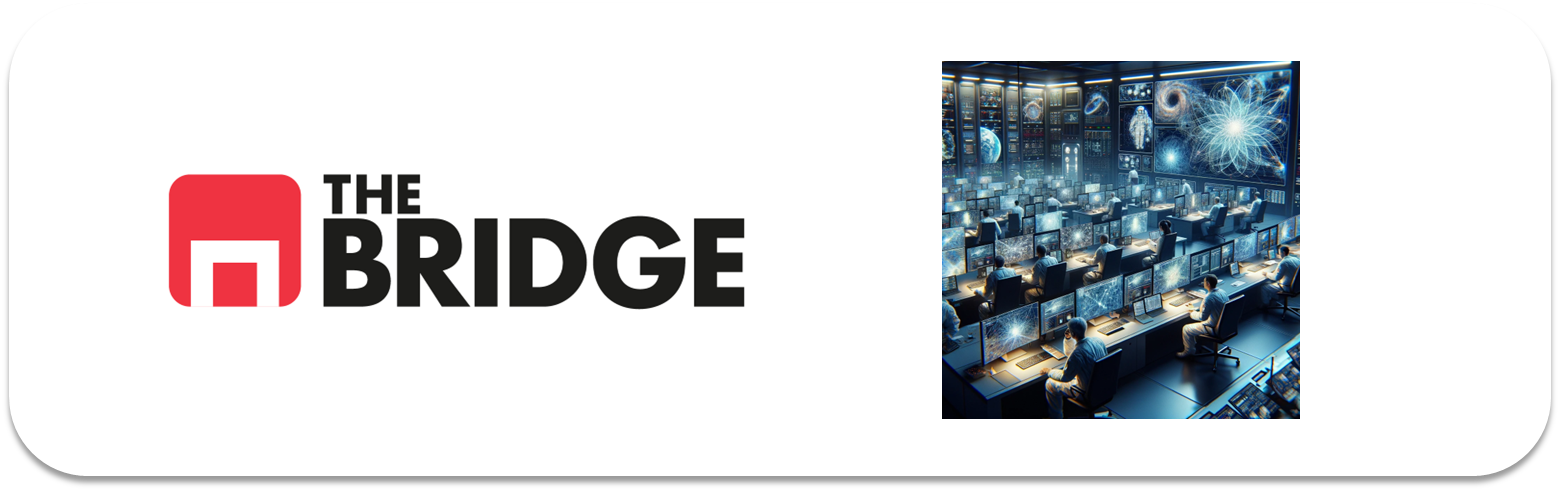

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

Cuando cogemos las imagenes, toda la informaicon que hay en el espacio de la imagen y la relacion entre todo lo que contiene la imagen se pierde porque lo reduciemmos solo a vectors lineales. EL modelo detecta patrones pero pierde lo que son relaciones posicionales, cómo estan las cosas en el espacio

Para solucionar esto aparecen las redes convolucionales - son redes neuronales que tienen como salida un perceptron multicapa e introducen un truco mat4ematico basado en la convolucion discreta : red neuronal con capas convolucionales

Problema de clasificacion binaria de imagenes en color de perros y gatos

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ds-online-tb/DS-Online/blob/main/05_Deep_Learning/Sprint_16/Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/18_Practica_Obligatoria_CNN_Redes_Convolucionales_SOL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [40]:
import bootcampviztools as bt
import cv2 # opencv
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd 
import random

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from skimage.io import imread

from tensorflow import keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

from time import time

pd.options.mode.copy_on_write = True # CoW por defecto a partir de pandas 3.0.0

Aparecen librerias como la de cv2 - computer vision 2 - usado para el ecosistema, librerias especificas para ver imagenes, vision por computador

Lo interesante de la practica: cómo trabaja una red convolucional o una capa convolucional. 

*Qué hace una capa convolucional? Las redes convolucionales se tienen a acumular, etc. qué hacen?*

Las cpaas convocluionales aplican una convolucion o realizar una convolucion;: recorrer la informacion den uestra imagen utilizando un sistema de barrido que va a recorrer la imagen iniciando el recorrido por el mismo lugar fila a fila descendiendo a lo largo de la imagen como si lo que hicieramos fueran pequeños escaneos o barridos. 

*Que obtiene o genera la convolucion??*

Cada uno de esos escaneos los realizara utilizando un recurso llamado Kernel o campo perceptivo. Esto es como si hablaramos de una mirilla: imaginemos que somos investigadores y que miramos una foto con una lupa y la vamos barriendo. Las redes convolucionales nunca tienen una percepcion completa de la imagen, siempre tienen una percepcion de la imagen parcial que depende del tamaño del kernel. Los kernels tienen habitualmente, son capaces de ver lo que estaocurriendo en varios pixels de la miagen, pero sutamaño dependera de la propia imagen. Si laimagen es pequeña necesitamos que el kernel vea aal menos 2 pixels, 5 pixels y si la imagen es mas grande necesitaremos ampliar el tamaño del kernel.

Un kernel muy pequeño en una imagen muy grande no sere capaz de detetcar nada intresnte de la imagen.

Ese kernel, esos barridos se ocupará de extraer caratceristicas de la imagen. 

*Que tipo de caracteristicas?*

A priori no lo sabemos de qué caractsr´siticas sacará la convolucion y cada uno de los kernels porque los filtros que generaran estas convoluciones se ajustan durante el entrenamiento de la red. Sera la propia red la que decida en cada foto qué imoprta y qué no importa

Convolucional: Operación matemática convolución 
1. Campo perceptivo = Kernel
2. Extractor de Features -> Aplanado + Modelo



### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



* Captcha visual de perros y datos para evitar ataques de denegacion de servicios
* Piden entrenar un modelo de clasificación que pueda emular ese potencial robot que nos quiere atacar para detectar las fotografías que a un robot le costaría más detectar como perro y como gato
* Tenemos que seleccionar sobre un conjunto de 1.000 imagenes, aquellas que peor se le daría a un sistema anti captcha
* Están distirbuidas en 4 directorios: 4 directorios de train y uno de test. Todas estaban identificadas por categoria (cat/dog) y el número de la imagen; en test hay de todo
* Tenemos que recorrer los directorios, extraer los datos y cargarlos en Python - cargarlos como arrays con sus valores

Tenemos que:
* crear los datasets
* A la vez que leemos las imagenes tenemos que adaptar su resolucion para que todas sean de 32x32 pixels - aumentamos la resolucion - al aumentar la resolucion aumentmaos la dimensionalidad, numero de neuronas, parametros etc. Podemos adaptar las funciones de los ejercicios de la unidad
* Una vez resuelto esto, creamos el modelo de deep learning: 2 pares o juegos de convolucional-pooling siguiendo el proceso clasico de machine learning
* Entrenar el modelo con un callback + mostrar el historial
* Evaluar el modelo
* Seleccionarl el 10% de imagenes mal clasificadas

### Resolución

### #1

#### Carga de Datos (y train test split de regalo)

*Vamos a crear los datasets, adaptamos la función para que en vez de admitir un único directorio admita una lista de ellos*

Leemos las imagenes con:
conforme  las vayamos cargando las leemos con imread() - lo convierte de jpg a arrays y desppues usamos la libreria de cv2 para hacer un resize - da igual que venga en horizontal, certical etc

al modelo todo lo que le daremos tendran las mismas proporciones - si estamos comprimiendo ocambiando formas de diversos formato es bueno porque le añade mas varianza al modelo: vera gatos con proporciones adeuadas y gatos con proporciones desproporcionadas, o por ejemplo tener una cabeza muy alargada o la cara muy chata. Añadirle varianza lo hará más robusto


In [9]:
def read_data(directorios, reshape_dim = (32,32)):
    X = [] 
    y = []
    mapa_imagen_fichero = []
    directorios = directorios if isinstance(directorios, list) else [directorios] if isinstance(directorios,str) else []
    for directorio in directorios:
        for file in os.listdir(directorio):
            image = imread('/'.join([directorio, file]))
            image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32
            X.append(image)
            y.append(file.split(".")[0]) # El nombre es la clase
            mapa_imagen_fichero.append(file) # Esto para ver la imagen al completo con su resolución

    return np.array(X),np.array(y),mapa_imagen_fichero

*Empezamos con el X_train, y_train a partir de los subdirectorios correspondientes*

Recorrer los directorios de data para ir sacando las imagenes

In [10]:
PATH_DATA = "./data/"
directorios  = [f"{PATH_DATA}github_train_{i}" for i in range(0,4)]
directorios

['./data/github_train_0',
 './data/github_train_1',
 './data/github_train_2',
 './data/github_train_3']

In [11]:
X_train, y_train, train_map = read_data(directorios)

*Ahora el test*

In [12]:
directorios  = [PATH_DATA + "github_test"]

X_test, y_test, test_map = read_data(directorios)

#### Visualización de datos

*Un pequeño vistazo al tipo y tamaño de nuestros datos*

Tenemos un array de 4 dimensiones (por los [[[[)- que contienen las 4 dimensiones del tensor? 
Tenemos la coleccion de imagenes, 4 dimensiones

La imagen son 3 dimensiones del tensor

Que tiene la imagen? El canal del color: 126, 100, 64

Cada uno de los vetcors es una combinacion de rojo - verde - azul (tecnica de codificacion para representacion de imagenes en medios electronicos)

Aqui con 3 puntos de color ya podemos recomponer una tonalidad o unos colores parecidos a los que vemos con los ojos

In [13]:
X_train

array([[[[126, 100,  64],
         [118,  92,  53],
         [129, 104,  63],
         ...,
         [ 88,  69,  45],
         [ 98,  40,  25],
         [121,  72,  50]],

        [[113,  92,  61],
         [122, 102,  68],
         [131, 111,  75],
         ...,
         [131,  75,  57],
         [ 99,  53,  23],
         [ 99,  42,  22]],

        [[120,  96,  64],
         [133, 110,  74],
         [126, 103,  63],
         ...,
         [ 79,  25,  12],
         [ 50,  12,   2],
         [ 79,  32,   6]],

        ...,

        [[ 15,  15,  10],
         [ 82,  79,  69],
         [ 73,  67,  51],
         ...,
         [103,  95,  69],
         [ 83,  75,  53],
         [ 98,  92,  60]],

        [[ 97,  99,  88],
         [ 66,  63,  49],
         [ 80,  69,  51],
         ...,
         [ 70,  61,  39],
         [ 88,  79,  61],
         [100,  92,  68]],

        [[ 63,  55,  44],
         [ 64,  55,  39],
         [ 82,  71,  50],
         ...,
         [ 86,  72,  46],
        

In [14]:
X_train.ndim

4

In [41]:
X_train.shape

(4000, 32, 32, 3)

Tiene 4.000 imagenes, 32x32 de resolucion y el 3 son los cnaales

*Train: 4000 imágenes, de 32x32 y en color, 3 canales*

In [16]:
type(X_train[123])

numpy.ndarray

In [17]:
X_train.dtype

dtype('uint8')

enteros de 8 bits - el valor mas alto sera ese 255

*Y son arrays como ya sabíamos porque es lo que retorna nuestra función :-)*

In [39]:
X_test.shape

(1000, 32, 32, 3)

Si intentamos sacar una imagen de test, la calidad de lo que tenemos es muy baja:

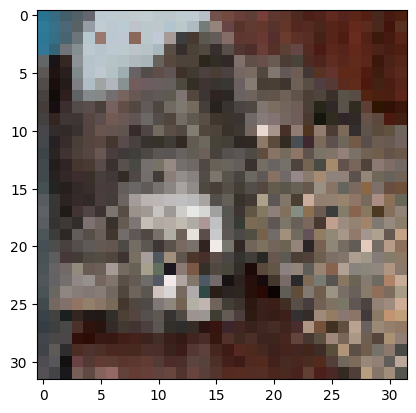

In [19]:
plt.imshow(X_test[3])

In [20]:
y_test[3]

np.str_('cat')

Vamos a probar otra:

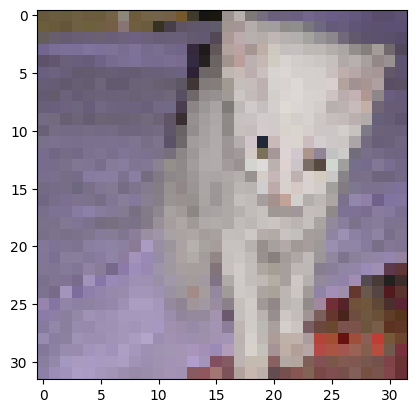

In [42]:
plt.imshow(X_test[5])

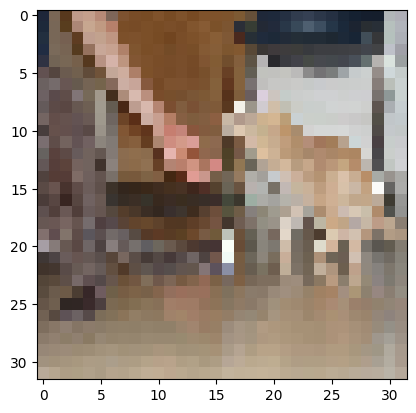

In [43]:
plt.imshow(X_test[4])

Habrá casos en que la red lo tendra mas facil y otros casos mas complicado

*Test: 1000 imágenes de 32x32, en color, 3 canales*

Para ver datos reutilizamos las funciones que teniamos en otros ejercicios:

*Para ver nuestros datos, reutilizamos directamente la función creada para el ejercicio de los paisajes*

In [44]:
def show_images_batch(pets, names = [], n_cols = 5, size_scale = 2):
    n_rows = ((len(pets) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1*size_scale))
    for index, pet in enumerate(pets):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(pet, cmap = "Greys")
        plt.axis("off")
        if len(names):
            plt.title(names[index])

In [45]:
def show_images_files(pets, names = [], n_cols = 5, size_scale = 2, train = True, indice = 0):
    n_rows = ((len(pets) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1*size_scale))
    for index, filepet in enumerate(pets):
        plt.subplot(n_rows, n_cols, index + 1)
        if train:
            pet = imread(PATH_DATA + f"github_train_{indice}/" + filepet)
        else:
            pet = imread(PATH_DATA + "github_test/" + filepet)
        plt.imshow(pet, cmap = "Greys")
        plt.axis("off")
        if len(names):
            plt.title(names[index])

*Veamos algunas seleccionadas aleatoriamente*

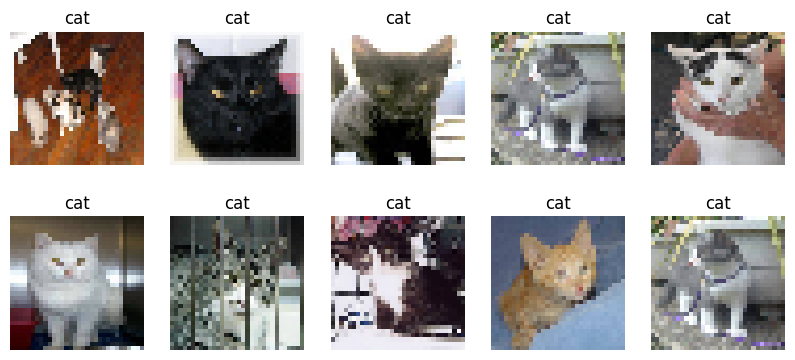

In [23]:
indices = np.random.randint(100,300,10)
show_images_batch(X_train[indices], names= y_train[indices])

Resolucion muy baja y ademas tiene varias proporciones: fotos verticales, fotos horizontales.... pero cuando las reshepeamos quedan deformadas

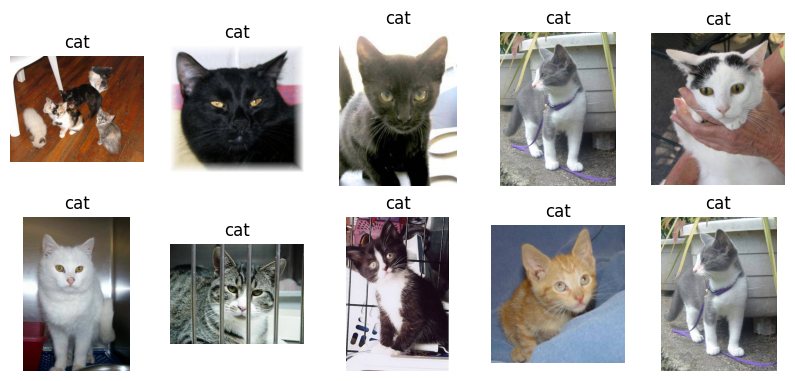

In [24]:
show_images_files([train_map[i] for i in indices], names= y_train[indices])

*Nos salen solo gatos porque están ordenados, veamos algunos simpáticos perritos*

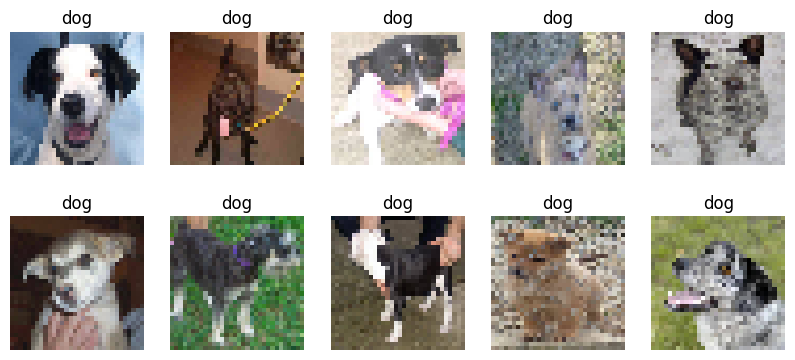

In [25]:
indices = np.random.randint(2000,2300,10)
show_images_batch(X_train[indices], names= y_train[indices])

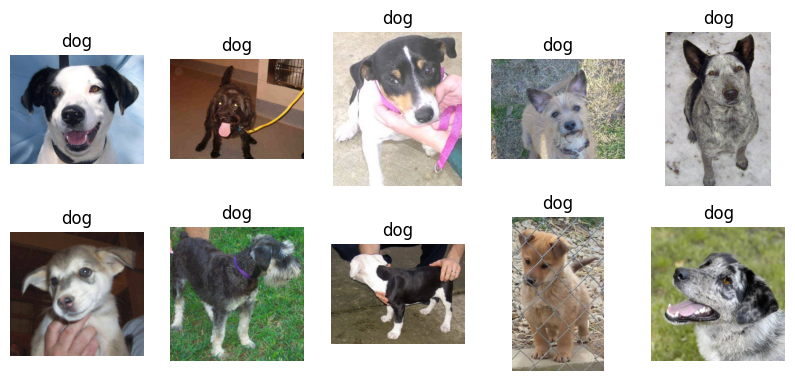

In [46]:
show_images_files([train_map[i] for i in indices], names= y_train[indices], train=2, indice=2)

Hay casos donde el animal esta cent5rado en la imagen y otros en los que no y puede ser que haya una foto con varios perros

#### MiniEDA

Como es un problema de imagenes no analizaremos los pixeles

*Como en todo modelo de ML, y DL es un subconjunto, vamos a analizar el target*

In [27]:
pd.Series(y_train).value_counts(True)

cat    0.5
dog    0.5
Name: proportion, dtype: float64

*Tenemos un dataset completamente equilibrado para un problema de clasificación binaria*

In [28]:
X_train.shape

(4000, 32, 32, 3)

In [29]:
X_train.dtype

dtype('uint8')

#### Escalado

*Siempre es interesante hacer un escalado aunque sea el caso de imágenes con los canales ya "escalados" entre 0 y 255. Reducir el rango de 0/255 a -1/1 o 0/1, aprovecha mejoras las funciones de activación y evita problemas de saturación.*

a las redes les sientan bien que los datos esten entre 0 y 1

Hay algunas redes que obligan a escalar entre -1 y 1: fine utning y transfer learning

In [30]:
X_train = X_train/255
X_test = X_test/255

In [31]:
X_train[0]

array([[[0.49411765, 0.39215686, 0.25098039],
        [0.4627451 , 0.36078431, 0.20784314],
        [0.50588235, 0.40784314, 0.24705882],
        ...,
        [0.34509804, 0.27058824, 0.17647059],
        [0.38431373, 0.15686275, 0.09803922],
        [0.4745098 , 0.28235294, 0.19607843]],

       [[0.44313725, 0.36078431, 0.23921569],
        [0.47843137, 0.4       , 0.26666667],
        [0.51372549, 0.43529412, 0.29411765],
        ...,
        [0.51372549, 0.29411765, 0.22352941],
        [0.38823529, 0.20784314, 0.09019608],
        [0.38823529, 0.16470588, 0.08627451]],

       [[0.47058824, 0.37647059, 0.25098039],
        [0.52156863, 0.43137255, 0.29019608],
        [0.49411765, 0.40392157, 0.24705882],
        ...,
        [0.30980392, 0.09803922, 0.04705882],
        [0.19607843, 0.04705882, 0.00784314],
        [0.30980392, 0.1254902 , 0.02352941]],

       ...,

       [[0.05882353, 0.05882353, 0.03921569],
        [0.32156863, 0.30980392, 0.27058824],
        [0.28627451, 0

In [32]:
X_train.dtype

dtype('float64')

#### Shuffle

Cuando los datos estan completamente ordenados es RECOMENDABLE HACER UN SHUFFLE - para limitar que a la red le llegue las imagenes tna orpdenadas y pueda no ver patrones, así los barajamos

Con los batches se produce una cierta aleatorizacion pero es recomendable hacer el shuffle

Y aprovechamos para construir un randomforest como baseline. OJO! Al randomforest no le podemos dar imagenes a color asi que hacemos la funcion siguiente para pasarlo a escala de grises y ademas se le tiene que hacer un flatten porque es lo que necesita random forest

*Como los datos están ordenados, es necesario darle cierta aleatoriedad, aunque internamente se van a procesar aleatoriamente al construir los batches, si de partida estan ordenado. Lo veremos más adelante*

*EXTRA: Construimos un randomforest como baseline*

In [33]:
def aplana_escala_gris(array_in, grises = True):
    def convertir_a_escala_de_grises(imagen_color):
        coeficientes = np.array([0.2989, 0.5870, 0.1140])
        imagen_gris = np.dot(imagen_color[...,:3], coeficientes)
        return imagen_gris

    if array_in.shape[-1] == 3 and grises:
        array_in = np.array([convertir_a_escala_de_grises(imagen) for imagen in array_in])
    return array_in.reshape(array_in.shape[0],-1)

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X_train_rf = aplana_escala_gris(X_train)
len(X_train_rf[0])


1024

así lo barajamos:

In [35]:
from sklearn.utils import shuffle

X_train_rf_shuffled, y_train_shuffled = shuffle(X_train_rf, y_train, random_state = 42)

Para que veamos como estaba antes y como esta despues del shuffled:

In [36]:
y_train[0:10]

array(['cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat',
       'cat'], dtype='<U3')

In [37]:
y_train_shuffled[0:10]

array(['cat', 'dog', 'cat', 'dog', 'dog', 'cat', 'cat', 'cat', 'cat',
       'cat'], dtype='<U3')

Un random forest classifier con una validacion cruzada con los datos convertidos a blanco y negro con vectores tendra un accuracy aprox del 61%!:

In [82]:
rf_clf = RandomForestClassifier()

np.mean(cross_val_score(rf_clf, X_train_rf_shuffled, y_train_shuffled, cv = 5, scoring = "accuracy"))

np.float64(0.6170000000000001)

*Un 61% de accuracy es lo mínimo que debemos exigir*

### #2 Modelo convolucional

*A la hora de crear un modelo DL, recuerda que necesitamos fijar una serie de hiperparámetros de partida, no es como cuando instanciamos nuestros modelos en Sklearn que ya vienen "preconfigurados". El orden en este caso suele ser:*

1. Topología (I): 
    - Capas, conexión entre capas, si vamos a hacer expansión-reducción de features, reducción-expansión, prismas, aplanamiento, dropout, etc.  
2. Topología (II):
    - Hiperparámetros por capa: unidades para las densas, kernel, strides, filtros, padding para convolucionales y pooling, drop-out rate para drop-out, etc.  
3. Otros hiperparámetros:
    - Tipo de optimizador (y sus hiperparámetros, en general usaremos los por defecto, salvo el learning rate en algunas ocasiones), tamaño del batch (aunque en general puede ser 32 y dependerá del tamaño del dataset de train y de nuestro hardware), épocas de entrenamiento, % del conjunto de validación.  
4. Métrica y función de pérdida:  
    - Para un dataset balanceado y un problema de clasificación binaria.
5. Uso de callbacks (en Keras):
    - En general usaremos o EarlyStopping y/o ModelCheckpoint, pero [aquí](https://keras.io/api/callbacks/) tienes unas cuantas más de las estándar de Keras  

*En este caso vamos a crear una topología parecida a la de la siguiente figura*

A diferencia de sklearn que nos venian ya los modelos (por ejemplo, random forest, sntancio, entreno y a funcionar) en DL no está y aparecen capas nuevas que no habiamos visto antes. En las convolucionales tenemos que definir la topologia del perceptron multicapa (va a estar presente en la mayoria de redes neuronales, sera la cabeza de salida de la mayoria de redes neruonales) - al perceptron multicapa le añadiremos un trasto por detras: entre la entrada y el perceptron y sera el que se ocupe de entender las imagenes a nivel espacial - el que hace que las imagenes sean imagenes, no como vectores.

Pero es que además de la topología del perceptron tenemos que pensar en la topologia de la estructura previa: aqui podemos pensar en no solo cuantas capas queremos poner sino trambien la conexion entre ellas, si haremos expasion reduccion de las caracteristicas, si metemos capas flatten de aplanamiento... etc (aqui estmos hablando del perceptron) y de las convolucionales decir que capas vamos a pobner (dropout entre ellas, de normalizacion,), tamaño de los kernels, metrica, funcion de perdida, los callbacks, etc.

Vamos a intentar recrear una estructura de este tipo:

* Tiene 2 pares de capas de convolucionales y pooling: entre ellas vamos a ir reduciendo la dimensionalidad de lo que seria la imagen original y entre ambas estructuras colocaremos una capa de dropout

* Que se pone a la salida de la estructura de convolucion? Un perceptron multicapa (es lo de la derecha, lo hemos estado haciendo en clases previas)

* Convolucionales: imaginemos ue tenemos las imagenes en blanco y negro. Las imagenes son punto de luz y representan un valor numerico en numpy. Lo que paranosotros puede ser una imagen de un amigo, para numpy simplemente es una matriz de números.

* Qué significa aplicar un kernel a la imagen? Cualquiera de los softwares de procesaiento de imagenes ya usan la convolucion disreta para transformar imagenes. El resultado de aplicar un kernel mediante una convolucion es la suma del producto matricial. Ejemplo  - difuminar una foto: aplica un kernel un campo perceptivo a lo largo de la imagen. Cogemos la matriz y la multiplicamos por loso valores de los 9 pixels (si es de 3x3): la suma del producto de es s  matrices da un valor escalar y se proyecta en la nueva imagen.

* Convolucion discreta: para generar los pixels tenemos que barrer el kernel y se hace fila a fila. Pasamos el kernel por toda la imagen fila a fila - esto es una **convolución discreta**

* En convolucionales cuando nos interesa mantener la dimensionalidad, se pone un padding a la imagen original. así empezare la convolucion arriba izq y lo del marco de pixels blancos. Si la imagen no tiene padding perdemos filas y columnas. Si le metemos el marquito blanco tenemos la imagen completa



La convolucion es coger el campo perceptivo, barrer toda la imagen, en cada uno de los pasos realizo la suma del producto de matrices, obtengo un escalar y pasa a la nueva imagen. Importante: 

#### Topología I-II:

*Vamos a construir una red como la de la figura:*



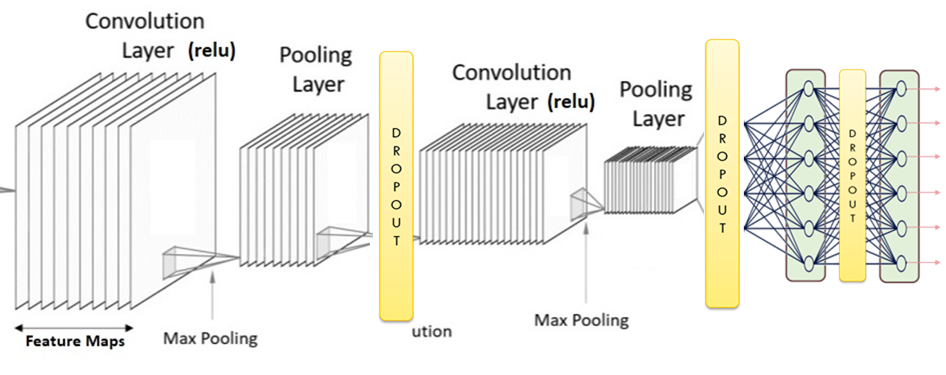

* **Conv Layer**: extraerá diferentes features de las imagenes
* **Pooling Layer**: Reduce las dimensiones de las imágenes tras una capa convolucional
* **Fully Connected Layer**: Tras las capas convolucionales, aplanamos las features y las introducimos como entrada de una red neuronal normal.
* **Output Layer**: Las predicciones de la red

*Con los siguientes hiperparámetros:*  

***Primer juego Conv-Pooling:*** 
* *Conv -> kernel de 3x3, stride = (1,1), padding = "same", activation = "relu", numero de filtros = 64*  
* *Pooling -> max, kernel 2x2, stride = (2,2)) -> Vamos a reducir en 2x2, 4 el número de features*  
* *Features de salida: 16*16*64 = 16384

*Capa Dropout: 0.25 de ratio*

***Segundo juego con Conv-Pooling:*** *Aplicamos expansión, aumentando el número de filtros, pensamos en buscar más características de características*  
* *Conv -> kernel de 3x3, stride = (1,1), padding = "same", activation = "relu", numero de filtros = 128*  
* *Pooling -> max, kernel 2x2, stride = (2,2)) -> Vamos a reducir en 2x2, 4 el número de features*  
* Features de salida 8*8*128 = 8192
  
*Capa Dropout: 0.25 de ratio*  

*Capa aplanadora: Flatten() -> Nos deja cada instancia en un vector de 8192 features  
***Cabeza clasificacion:*** *1 densa oculta y la de salida. La oculta empezamos con una reducción de 8192 a 512, un factor de 16. Podríamos haberla dejado en 32x32 = 1024 features que es el número que meteríamos en un modelo tradicional*
* *Capa Oculta Densa: 128 unidades, activación "relu"*
* *Capa densa de salida: 1 unidad (es clasificador binario), activación "softmax"*


Los kernels se inicializan con numeros y pesos aleatorios y sera la red durante el entrenamiento la que deteara los kernels y tenemos tantos kernels diferentes como filtros tenemos en las cpas (o mapas de caracteristicas)

Ejemplo:  keras.layers.Conv2D(64, (3,3)

* 64 filtros: vamos a crear 64 versiones, 64 reinterpretaciones de nuestra imagen original (conocid como filtro o mapa  de caracteristica). Y cada uno resaltara caracteristicas que a priori no podemos saber

Para construirlo: 

* Le vamos a pedir una lista de capas y despues se lo damos al consntructor secuencial
* Tenemos un input, entrada: con imagenes de 32x32 y en este caso 3 canales. Cada uiagen sera un tensor de 3 dimensiones.
* Conv2D: Este 32, 32 se lo pasamos a la red convolucional y le decimos quiero que realices una convolucion discreta con kernels de un tamaño 3x3 en una imagen de 32x32. Respecto el tamaño: en cada imagen estamos viendo practicamente un 9% de la imagen aproximadamente, estamos viendo bastante trozo de imagen cada vez que le hacemos un barrido. Esto nos indica que la imagen es tan pequeña que al realizar la convolucion podemos estar detectando caracteristicas. Si la imagen fuera de 320x320 el kernel de 3x3 probablemente no veria nada. Si la imagen es muy grande y mi kernel pequeño, veria muy poca cosa porque seria una imagen super grande para un kernel super pequeño. Tendria que ser un tamaño proporcional un poco al tamaño de las imagenes, o sea que el kernel sea proporcional. Por ejemplo, un 10% de la imagen. Pasamos de una imagen con 3 canales a 64 mapas para cada imagen - tenemos 64 mapas de caractsristicas para cada imagen de 32x32 y esto puede hacer que la red crezca muchisimo de tamaño. 
* MaxPooling2D: Para condensar la informacion le metemos una reduccion de la dimensionalidad,es decir, una capa de max pooling. Barren los mapas de caracteristicas resultantes. Y la capa de mmaxpooling lo que hace es que dado unu tamaño de pool de 2,2 (2x2) divide la imagen por sectores en pools del tamaño que le hayamos indicado y cada uno de esos pools se queda con el valor maximo. Por ejemplo, un hipotetico mapa de caracteristicas de 4x4 si le aplicamos un max pool de 2x2 con un stride de 2 (es lo habitual en estos casos), nos estamos quedando con el valor maximo de esos 4 valores). En nuestro caso, teniamos el mapa de 64 y al pasarlo por pool_size = (2,2) lo estamos dividiendo por 2: 32x32/2 = 16x16 (equivale a hacer una division por 2 de la resolucion). Los mapas de caracterisicas son ahora de 16x16 pero recuerda que aun tenemos 64, hemos ganado mapas en profundidad

   *  De cada pool se queda con el valor máximo: dividimos a 16x16 (entre 2 llos 32x32)

* Dropout:

El siguiente bloque de convolucionales no aplica sobre lo que era la imagen, sino que se aplica sobre los **mapas de caracteristicas**:
* Conv2D: Aqui le hemos dicho (128, (3,3) - que aplique una convolucional de 128 filtros con un kernel de 3x3. que profundidad tendra el kernel? Ya no mira la imagen, mira el mapa de caracteristicas: este kernel recorre todos los filtros resultantes de la convolucion previa - es de 3x3 x64 de profundidad. Lo que estamos generando son 128 nuevos filtros pero que condensan la informacion de los 64 filtros previos (64 los estamos barriendo 128 vecesy estamos sacando 128 mapas nuevos de 16x16)
    *  Cuando le paso otra convolucional el filtro ya no mira 32 canales, mira 64 y miramos 128 filtros de 3x3x64. No estoy reduciendo la dimensionalidad, estoy produciendo nuevos mapas de caracteristicas

* MaxPooling2D: reduce en el sentido 32x32 para permitirme volver a crecer e ir manteniendo en un tamaño adecuado la red. Ahora mediran 8x8 porque los hemos vuelto a dividir. 
* Dropout:

  
Y con esto que hacemos? Aplanarlo coon FLATTEN: mapas de caracteristicas de las mapas de caracteristicas de la imagen. Reduce la imagen y va sacando datos de las partes mas pequeñas!

Siguiente bloque convolucional:

* Flatten:
* Dense:
* Dropout:
* Dense:

El **dropout** lo que hace es desactiva conexiones, es como poner funciones d eactivacion a 0 pero lo hace de manera aleatoria en cada una de las pasadas del entrenamiento de la red. Es decir, el dropout no significa que yo de repente corte las conexiones, no significa que yo corte aleatoriamente el 25% de las conexiones entre neuronas. Significa que durante la pasada de los entrenamientos, es como si yo fuera el entrenador y quisiera putear a la red y en cada pasada yo voy y apago el 25% de estas conexiones de forma aleatoria. Es como si esas conexiones no existieran en esa pasada, fuerzo a la red a que trabaje con el 75% de las conexiones restantes en esa pasada. Esa red realiza una pasada, realiza una prediccion y esa prediccion comete un error: ese error lo propago hacia atrás pero las conexiones que yo habia desactivado no las ajusto; no las he usado para esa prediccion, no las ajusto en retroprogpagacion porqye no las he usado. Pero en la siguiente pasada voy a desactivar otro 25% aleatorio asi que a lo mejr pillo alguna que se habia entrenaddo antes, alguna que no, etc. En cada pasada de foward pass y de back propagation, la distirbucion de neuronas es diferente porque solo estan activas 

In [51]:
layers = [
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Conv2D(64, (3,3), activation = 'relu', padding= "same"), # Padding "Valid" (sin padding), "Same" (ajusta para que entre todo), Integer -> el relleno que yo quiera. 
    keras.layers.MaxPooling2D(pool_size = (2,2), padding = "same"), # 2x2 -> A dividir por 2 la resolución de cada dimensión de la capa anterior, 32x32 -> 16x16 
    keras.layers.Dropout(rate = 0.25),

    keras.layers.Conv2D(128, (3,3), activation = 'relu', padding= "same"),
    keras.layers.MaxPooling2D(pool_size = (2,2), padding = "same"), # 16x16 -> 8x8
    keras.layers.Dropout(rate = 0.25),
    
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'), # 1024 -> 32*32
    keras.layers.Dropout(rate = 0.5),
    #keras.layers.Dense(2, activation='softmax') # -> loss = "sparse_categorical_crossentropy" (categorical_crossentropy es cuando y_train = [0,1] o y_train = [0,0,1,0,0]
    keras.layers.Dense(1, activation='sigmoid') # -> loss = "binary_crossentropy"
]

model = keras.Sequential(layers)

#### Otros hiperparámetros

*Veamos el tamaño de entrada de datos:*

In [52]:
X_train.size

12288000

*Nos vale un Adam, podríamos probar un SGD*

In [53]:
optimizer = keras.optimizers.Adam()

In [54]:
metrics = ["accuracy"] # dataset equilibrado
loss = "binary_crossentropy" # Es un clasificador binario

*Tenemos 4000 instancias, no son tantas así que emplearemos un batch size de 32*

In [55]:
batch_size = 32

len(X_train)*0.8/batch_size

100.0

*Cada época tendrá 100 pasadas por el algoritmo de entrenamiento, también llamados steps. Incluso podríamos aumentar a 48-64 el batch_size*

*Escogemos un número alto de épocas y usamos un EarlyStopping con paciencia 10 para no tener que depender del número de épocas*

In [56]:
num_epochs = 100

In [57]:
earlyS = keras.callbacks.EarlyStopping(patience = 10)

*Compilamos y mostramos un resumen del modelo*

In [58]:
model.compile(optimizer= optimizer,
              loss= loss,
              metrics= metrics)

In [59]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,270,977 (16.29 MB)

 Trainable params: 4,270,977 (16.29 MB)

 Non-trainable params: 0 (0.00 B)

### #3

*Hora de entrenar y mostrar ese entrenamiento, pero primero vamos a lanzar una sóla época para ver tiempos y antes convertir el target a numérico*

In [60]:
y_train[np.array([1,2,3560])]

array(['cat', 'cat', 'dog'], dtype='<U3')

In [61]:
y_train_num = np.array([0 if y == "cat" else 1 for y in y_train]) # Tiene que ser un array de numpy o no lo admitirá el fit si queremos validation set

*Como vamos a tener que lanzar varios entrenamientos para poder simular un reseteo de pesos creamos una función que nos hace eso, nos devuelve el modelo preparado para un nuevo fit*

In [62]:
def prepare_model(resolucion = (32,32)):
    layers = [
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Conv2D(64,(3,3), activation = 'relu', padding= "same"),
    keras.layers.MaxPooling2D(pool_size = (2,2), padding = "same"),
    keras.layers.Dropout(rate = 0.25),
    
    keras.layers.Conv2D(128,(3,3), activation = 'relu', padding= "same"),
    keras.layers.MaxPooling2D(pool_size = (2,2), padding = "same"),
    keras.layers.Dropout(rate = 0.25),
    
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(rate = 0.5),
    keras.layers.Dense(1, activation='sigmoid')
    ]
    
    model = keras.Sequential(layers)
    optimizer = keras.optimizers.Adam()
    metrics = ["accuracy"] # dataset equilibrado
    loss = "binary_crossentropy" # Es un clasificador binario
    
    model.compile(optimizer= optimizer,
              loss= loss,
              metrics= metrics)
    
    return model
    

*Podemos probar un entrenamiento con una única época y extrapolar la duración de nuestro hipotético entrenamiento posterior con 100 épocas, pero ojo que **esto no debe hacerse si el entrenamiento se realiza con GPU** porque en ese caso la primera época siempre es mucho más lenta que el resto.*

In [63]:
model = prepare_model()

t_zero = time()

history = model.fit(X_train,
          y_train_num,
          epochs=1,
          batch_size= batch_size,
          callbacks = [earlyS],
          validation_split=0.2)

dur_epoca = time()-t_zero

100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.6319 - loss: 0.6549 - val_accuracy: 0.7425 - val_loss: 0.6343


In [64]:
print(dur_epoca)

6.719446659088135


*5-6 segundos podemos usar un número alto de épocas, pero eso sí ojo con los resultados por si son excesivamente positivos, tendríamos que estar preocupados.*  

*Entrenamos ahora con los datos ORDENADOS (sin shuffle) y guardamos los datos de entrenamiento en la variable history.*

In [65]:
model = prepare_model()

t_zero = time()

history = model.fit(X_train,
          y_train_num,
          epochs= num_epochs,
          batch_size= batch_size,
          callbacks = [earlyS],
          validation_split=0.2)

dur_epoca = time()-t_zero

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.6144 - loss: 0.6699 - val_accuracy: 0.0012 - val_loss: 0.7777
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.6497 - loss: 0.6261 - val_accuracy: 0.4400 - val_loss: 0.7858
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.6712 - loss: 0.6031 - val_accuracy: 0.5650 - val_loss: 0.7213
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.7019 - loss: 0.5756 - val_accuracy: 0.6637 - val_loss: 0.6384
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.7153 - loss: 0.5452 - val_accuracy: 0.6275 - val_loss: 0.6562
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.7278 - loss: 0.5336 - val_accuracy: 0.5213 - val_loss: 0.7913
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.7550 - loss: 0.5007 - val_accuracy: 0.5225 - val_loss: 0.8491
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.7684 - loss: 0.4814 - 

In [66]:
y_test_num = np.array([0 if y == "cat" else 1 for y in y_test])

results = model.evaluate(X_test, y_test_num)
results

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7550 - loss: 0.7107


[0.7107456922531128, 0.7549999952316284]

*Como sabes, estos resultados pueden estar afectados por el orden de los datos de entrada (recuerda que estaban completamente ordenados, primero 2000 gatos y luego 2000 perros). Vamos a shufflearlos y volvemos a entrenar.*

In [51]:
#from sklearn.utils import shuffle

In [67]:
X_s, y_s = shuffle(X_train,y_train_num)

In [68]:
model = prepare_model()

t_zero = time()

history_shuffle = model.fit(X_s,
          y_s,
          epochs= num_epochs,
          batch_size= batch_size,
          callbacks = [earlyS],
          validation_split=0.2)

dur_epoca = time()-t_zero

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5347 - loss: 0.6947 - val_accuracy: 0.5213 - val_loss: 0.6798
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.6028 - loss: 0.6584 - val_accuracy: 0.6137 - val_loss: 0.6675
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.6475 - loss: 0.6313 - val_accuracy: 0.6988 - val_loss: 0.5992
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.6822 - loss: 0.5892 - val_accuracy: 0.6750 - val_loss: 0.5917
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7094 - loss: 0.5627 - val_accuracy: 0.7337 - val_loss: 0.5502
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.7303 - loss: 0.5331 - val_accuracy: 0.7212 - val_loss: 0.5340
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7541 - loss: 0.5023 - val_accuracy: 0.7400 - val_loss: 0.5263
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7609 - loss: 0.4891 - 

In [69]:
y_test_num = np.array([0 if y == "cat" else 1 for y in y_test])
results = model.evaluate(X_test,y_test_num)
print("test loss, test acc:", results)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7350 - loss: 0.5592
test loss, test acc: [0.559183657169342, 0.7350000143051147]


> *Nota: Los valores que se imprimen en pantalla durante la evaluación son medias móviles calculadas a lo largo del proceso de inferencia. La variable *results* contiene la pérdida (loss) y el acierto (accuracy) medio final, calculados a través de todos los *batches* o lotes del conjunto de datos de prueba. **Son estos resultados finales los que debemos usar para evaluar el rendimiento de nuestro modelo contra el conjunto de datos de prueba.***

*Los resultados contra test son similares con los datos ordenados y desordenados, pero si pintamos la evolución de los dos entrenamientos veremos que con los datos desordenados ayudamos a la red a converger.*

In [70]:
df_evol = pd.DataFrame(history.history)
df_evol_shuffle = pd.DataFrame(history_shuffle.history)

<Axes: >

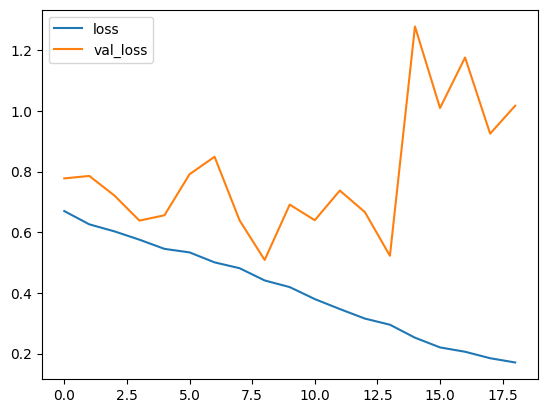

In [71]:
df_evol[["loss","val_loss"]].plot()

<Axes: >

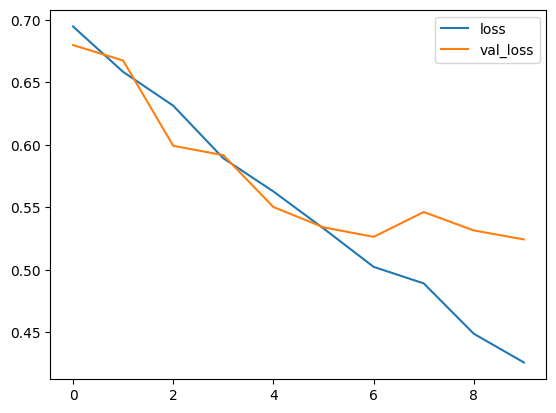

In [72]:
df_evol_shuffle[["loss","val_loss"]].plot()

*No siempre debemos parar en cuanto val y train se separan pero tampoco esperar mucho más. El no aleatorizar de primeras hace que el entrenamiento sin shuffling sea más oscilante, pero en este caso el impacto ha sido menor (recuerda que durante el fit de los modelos keras los batches se generan con aleatoreidad).*

### #4

In [73]:
predictions = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


*Nuestra neurona de salida con activación sigmoide nos devuelve las probabilidades de 0 a 1, de modo que:*
- *Probabilidad menor o igual a 0.5 -> Predice clase 0 (gatete)*  
- *Probabilidad mayor que 0.5 -> Predice clase 1 (perrete)*  

*Por tanto, par poder imprimir el reporte de clasificación o la matriz de confusión debemos recuperar nuestras etiquetas originales con, por ejemplo, una comprensión de lista.*

In [74]:
y_pred = ["dog" if prediction[0] > 0.5 else "cat" for prediction in model.predict(X_test)]
print(classification_report(y_test, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
              precision    recall  f1-score   support

         cat       0.72      0.77      0.74       500
         dog       0.75      0.70      0.72       500

    accuracy                           0.73      1000
   macro avg       0.74      0.73      0.73      1000
weighted avg       0.74      0.73      0.73      1000



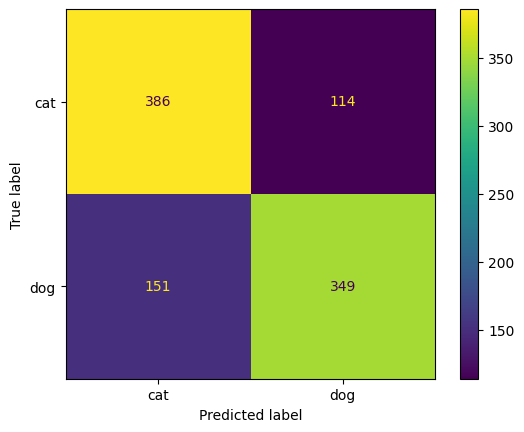

In [75]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

*Capta más gatos pero al precio de ser menos preciso a la hora de escoger gatos, dice que son más gatos de los que son, es más preciso con los perros y por eso los capta en menor número.*

### #5

*Para seleccionar aquellas imagenes que el modelo confunde con mayor confianza podemos aprovechar que el test está también ordenado:*

*Recuerda, si la probabilidad es menor o igual a 0.5 el modelo pensará que es un gato, y lo pensará con mayor confianza cuanto menor sea la probabilidad -> por tanto, podremos hacer la operación "1 menos probabilidad de la neurona" para conocer esa confianza.*  

*Así mismo, si la probabilidad es mayor que 0.5 el modelo pensará que es un perro, y lo pensará con mayor confianza cuanto mayor sea la probabilidad -> por tanto, no es necesario hacer ninguna operación, ya tenemos la confianza.*

In [76]:
confianza = [ (1-prediction[0]) if prediction[0] <= 0.5 else prediction[0] for prediction in model.predict(X_test)]
df_pred = pd.DataFrame({"ficheros": test_map,"True": [file.split(".")[0] for file in test_map],"Prediction": y_pred, "Confianza": confianza})
df_pred

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


,ficheros,True,Prediction,Confianza
0,cat.10705.jpg,cat,cat,0.510819
1,cat.10711.jpg,cat,cat,0.603280
2,cat.10714.jpg,cat,cat,0.821797
3,cat.10715.jpg,cat,dog,0.609344
4,cat.10716.jpg,cat,dog,0.817011
...,...,...,...,...
995,dog.9883.jpg,dog,dog,0.543556
996,dog.9884.jpg,dog,dog,0.576013
997,dog.9885.jpg,dog,dog,0.731491
998,dog.9889.jpg,dog,dog,0.685716


In [77]:
errores = df_pred["True"] != df_pred["Prediction"]
son_gatos = df_pred["True"] == "cat"
son_perros = df_pred["True"] == "dog"
gatos_dificiles = df_pred[son_gatos & errores]["Confianza"].nlargest(int(len(df_pred[son_gatos & errores])*0.1)).index.to_list()
perros_dificiles = df_pred[son_perros & errores]["Confianza"].nlargest(int(len(df_pred[son_perros & errores])*0.1)).index.to_list()


In [78]:
df_pred.loc[gatos_dificiles]

,ficheros,True,Prediction,Confianza
337,cat.11793.jpg,cat,dog,0.998673
175,cat.11240.jpg,cat,dog,0.951408
247,cat.11534.jpg,cat,dog,0.945059
13,cat.10740.jpg,cat,dog,0.927024
368,cat.11899.jpg,cat,dog,0.893206
8,cat.10728.jpg,cat,dog,0.887572
359,cat.11867.jpg,cat,dog,0.868533
239,cat.11492.jpg,cat,dog,0.866455
141,cat.11139.jpg,cat,dog,0.864527
153,cat.11168.jpg,cat,dog,0.857600


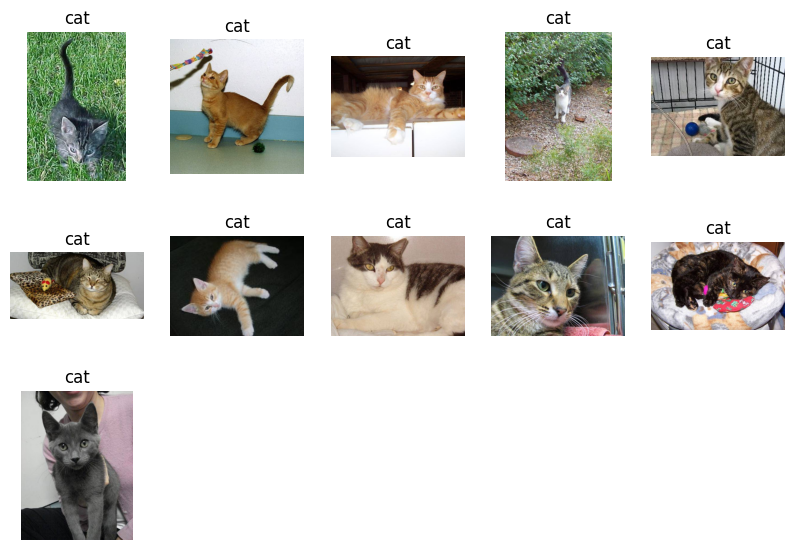

In [79]:
show_images_files(df_pred.loc[gatos_dificiles]["ficheros"], df_pred.loc[gatos_dificiles]["True"].values, train = False)

In [80]:
df_pred.loc[perros_dificiles]

,ficheros,True,Prediction,Confianza
662,dog.8696.jpg,dog,cat,0.996165
680,dog.8764.jpg,dog,cat,0.995393
888,dog.9509.jpg,dog,cat,0.993741
871,dog.9449.jpg,dog,cat,0.990162
930,dog.9639.jpg,dog,cat,0.988364
598,dog.8451.jpg,dog,cat,0.986155
851,dog.9346.jpg,dog,cat,0.981575
537,dog.8215.jpg,dog,cat,0.978585
613,dog.8507.jpg,dog,cat,0.972219
603,dog.8485.jpg,dog,cat,0.968066


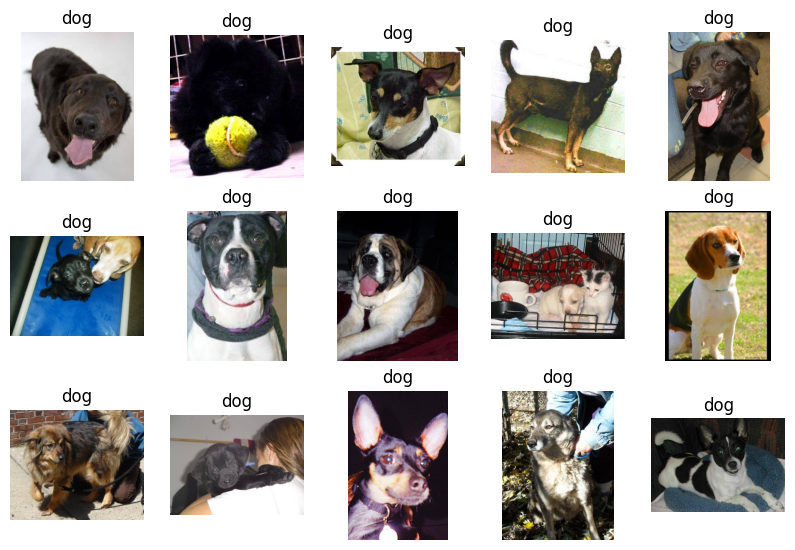

In [81]:
show_images_files(df_pred.loc[perros_dificiles]["ficheros"], df_pred.loc[perros_dificiles]["True"].values, train = False)

*La discusión es si la resolución afecta, que sí y tendríamos que hacerlo suponiendo esa resolución. Por otro lado, el que sean imágenes que a un humano no le costarían pero sí a un modelo las hace más idóneas para el trabajo porque fallarlas es signo inequívoco de que es un modelo*

### EXTRA

*Para terminar vamos a ver una de las técnicas que se pueden emplear para tener más informacio´n en un clasificador de imágenes (y que podría servir hasta cierto punto como técnica de generación sintética o oversampling para equilibrar datasets)*

*Vamos a ver cómo usar los augmentadores de datasets de keras para imágenes*

#### Image data generator

*Primero vamos a coger el train y vamos a construir un dataset con la estructura filename-category que nos servirá después para ver otra capacidad de keras*

In [67]:
directorios  = [f"{PATH_DATA}github_train_{i}" for i in range(0,4)]
ficheros = []
clases = []
for directorio in directorios:
    ficheros += [directorio + "/" + fichero for fichero in os.listdir(directorio)]
    clases += [fichero.split(".")[0] for fichero in os.listdir(directorio)]
train_augmented = pd.DataFrame({"filename": ficheros,"category": clases})
train_augmented.head(10)

    

,filename,category
0,./data/github_train_0/cat.1000.jpg,cat
1,./data/github_train_0/cat.10010.jpg,cat
2,./data/github_train_0/cat.10012.jpg,cat
3,./data/github_train_0/cat.10013.jpg,cat
4,./data/github_train_0/cat.10017.jpg,cat
5,./data/github_train_0/cat.1002.jpg,cat
6,./data/github_train_0/cat.10023.jpg,cat
7,./data/github_train_0/cat.10024.jpg,cat
8,./data/github_train_0/cat.10027.jpg,cat
9,./data/github_train_0/cat.10030.jpg,cat


*El objeto ImageDataGenerator va a servirnos para generar una imagen modificada de una imagen original, mediante rotaciones, reescalados, desplazamientos, zooms, flips, etc*

In [68]:
'''
NO genera X imagenes sinteticas. Simplemente en cada epoch, en vez de coger el
dataset tal cual lo tiene, coge una de esas imágenes sintéticas, algo diferentes,
Asi aumentan sus perspectivas
Las imagenes las va generando segun entrena
https://www.analyticsvidhya.com/blog/2020/08/image-augmentation-on-the-fly-using-keras-imagedatagenerator/

'''

example_df = train_augmented.sample(n=1).reset_index(drop=True)

train_datagen = ImageDataGenerator(
    rotation_range=15, # Angulo de rotación
    rescale=1./255, # Escalado, ya nos escala las imágenes
    shear_range=0.1, # Inclina las imágenes, no es giro es inclinación como hacerlas "cursivas"
    zoom_range=0.2, # Zoom
    horizontal_flip=True, # giro horizontal o especular
    width_shift_range=0.1, # Desplazamiento horizontal de los pixeles
    height_shift_range=0.1 # Desplazamiento vertical de los píxeles
)


*Dos formas de utilizarlo, desde la lectura de ficheros y desde los datos*

In [69]:
example_df

,filename,category
0,./data/github_train_3/dog.10432.jpg,dog


In [70]:

example_generator = train_datagen.flow_from_dataframe(
    example_df, 
    x_col='filename',
    y_col='category',
    target_size=(32, 32),
)

Found 1 validated image filenames belonging to 1 classes.


*Generamos ahora 15 imágenes sintéticas, se le aplican los cambios aletoriamente*

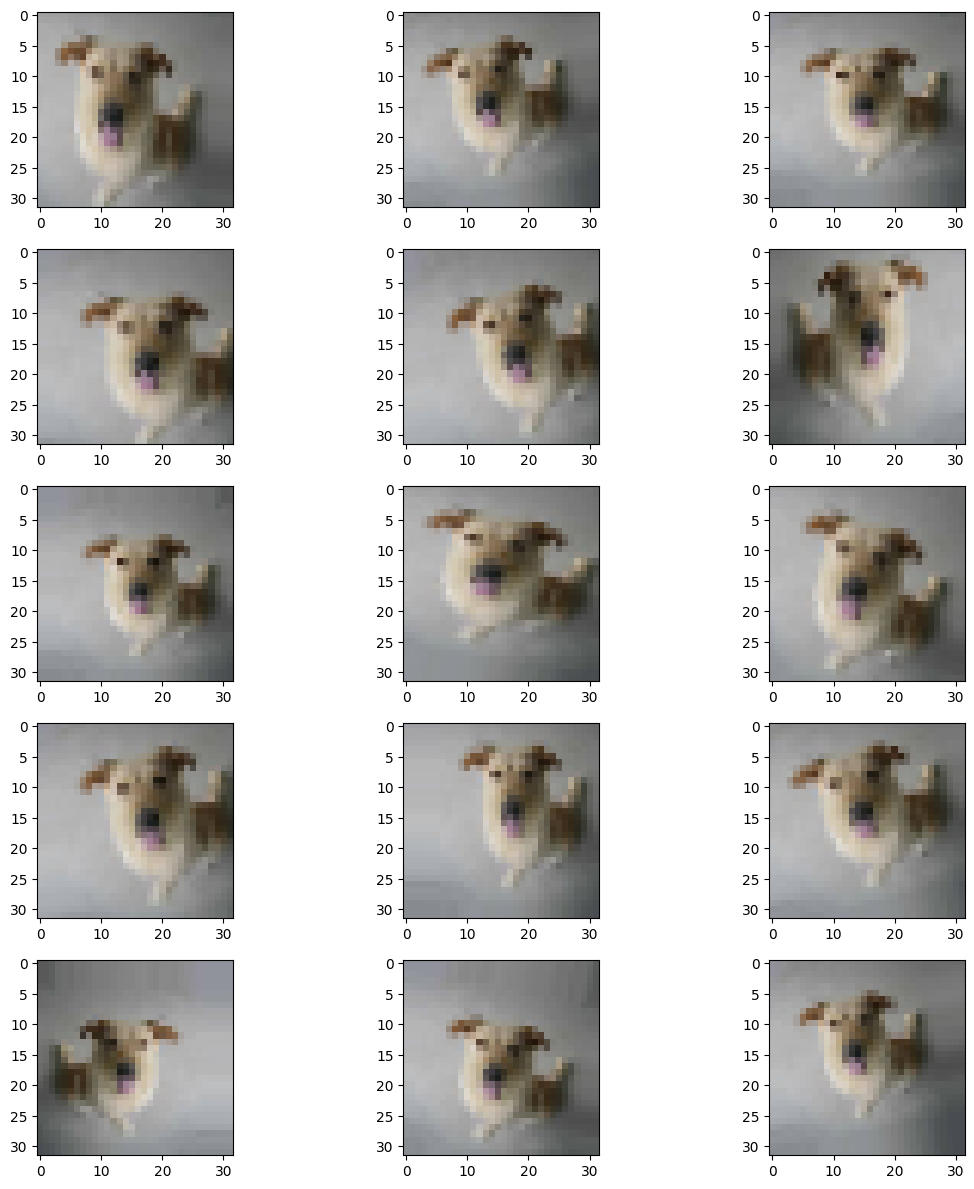

In [71]:
plt.figure(figsize=(12, 12))

for i in range(0, 15):
    plt.subplot(5, 3, i+1)
    for X_batch, Y_batch in example_generator:
        image = X_batch[0]
        plt.imshow(image)
        break
    
plt.tight_layout()
plt.show()

In [72]:

example_generator = train_datagen.flow(
    X_train[0:3]*255,
    y_train[0:3]
)

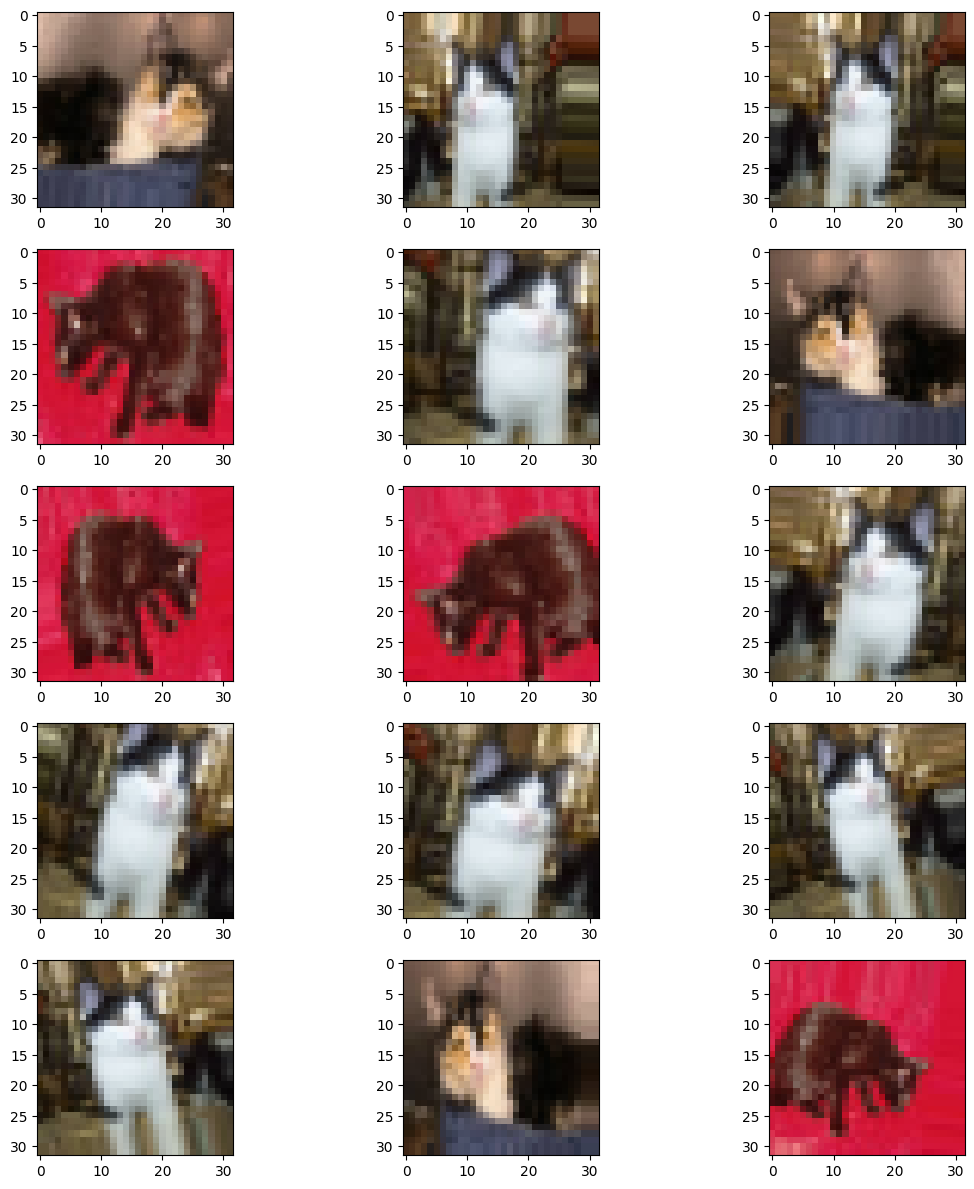

In [73]:
plt.figure(figsize=(12, 12))

for i in range(0, 15):
    plt.subplot(5, 3, i+1)
    for X_batch, Y_batch in example_generator:
        image = X_batch[0]
        plt.imshow(image)
        break
plt.tight_layout()
plt.show()

#### Aplicado a un modelo y un entrenamiento

*Tenemos que generar el dataset de validación aparte, porque ese no va a llevar aumentación*

In [74]:
train_df, validate_df = train_test_split(train_augmented,
                                         test_size=0.20,
                                         random_state=42)

In [75]:
train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

In [76]:
train_df

,filename,category
0,./data/github_train_3/dog.9982.jpg,dog
1,./data/github_train_0/cat.2440.jpg,cat
2,./data/github_train_2/dog.9981.jpg,dog
3,./data/github_train_1/cat.1657.jpg,cat
4,./data/github_train_0/cat.2753.jpg,cat
...,...,...
3195,./data/github_train_1/cat.1303.jpg,cat
3196,./data/github_train_1/cat.1882.jpg,cat
3197,./data/github_train_0/cat.487.jpg,cat
3198,./data/github_train_3/dog.11270.jpg,dog


In [77]:
total_train = train_df.shape[0]
total_validate = validate_df.shape[0]

print("Shape train", total_train)
print("Shape validation", total_validate)
validate_df.head()

Shape train 3200
Shape validation 800


,filename,category
0,./data/github_train_0/cat.2936.jpg,cat
1,./data/github_train_3/dog.11231.jpg,dog
2,./data/github_train_0/cat.2820.jpg,cat
3,./data/github_train_3/dog.12368.jpg,dog
4,./data/github_train_2/dog.9978.jpg,dog


# Training Generator

In [78]:
train_generator = train_datagen.flow_from_dataframe(
    train_df, 
    x_col='filename',
    y_col='category',
    target_size=(32, 32),
    class_mode='binary', # Porque es binaria, si fuera multiclase y en un sólo valor -> "sparse" (otras configuraciones, ver la documentación)
    batch_size= batch_size
)

Found 3200 validated image filenames belonging to 2 classes.


### Validation Generator

In [79]:
validation_datagen = ImageDataGenerator(rescale=1./255) # Solo vamos a reescalar

validation_generator = validation_datagen.flow_from_dataframe(
    validate_df, 
    x_col='filename',
    y_col='category',
    target_size=(32, 32),
    class_mode='binary',
    batch_size= batch_size
)

Found 800 validated image filenames belonging to 2 classes.


# Fit Model

In [80]:
model = keras.Sequential(layers)

model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [81]:
history = model.fit(
    train_generator, 
    epochs= num_epochs,
    validation_data=validation_generator,
    callbacks= earlyS
)

c:\Users\rodri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 195ms/step - accuracy: 0.4948 - loss: 0.7937 - val_accuracy: 0.5075 - val_loss: 0.6926
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.5270 - loss: 0.6914 - val_accuracy: 0.5775 - val_loss: 0.6685
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 188ms/step - accuracy: 0.5870 - loss: 0.6738 - val_accuracy: 0.6862 - val_loss: 0.6376
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.6181 - loss: 0.6550 - val_accuracy: 0.5888 - val_loss: 0.6863
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.6347 - loss: 0.6455 - val_accuracy: 0.6862 - val_loss: 0.5926
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.6506 - loss: 0.6234 - val_accuracy: 0.7138 - val_loss: 0.6035
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.6507 - loss: 0.6208 - val_accuracy: 0.6587 - val_loss: 0.6067
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.6537 - loss: 0

( caracteristicas,10), (caracteristicas,100) ->  Undersampling -> (caractaeristicas_gatos,10),(caract_perros,10);
(gatos,10),(perros,100) -> (gatos,10)+(gatos_inventadas,90), (perros,100)
class_weight

In [82]:
results = model.evaluate(X_test, y_test_num)
print("test loss, test acc:", results)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6569 - loss: 0.6207
test loss, test acc: [0.5054753422737122, 0.7459999918937683]


*Ahora probemos a realizar de una imagen que no está en ninguno de nuestros sets.*

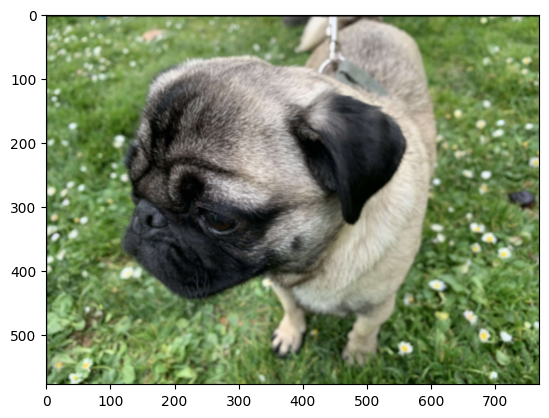

In [83]:
image = imread('gini_test.png')
plt.imshow(image);

In [84]:
image.shape

(577, 770, 4)

In [85]:
# Ajustamos tamaño y normalizamos
image = np.array([cv2.resize(image, (32, 32))/255])

In [86]:
image.shape

(1, 32, 32, 4)

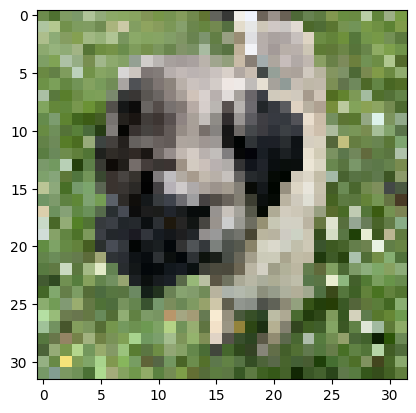

In [87]:
plt.imshow(image[0])
plt.show()

In [88]:
predictions = model.predict(image).round(3)
print("predictions shape:", predictions.shape)

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "conv2d" is incompatible with the layer: expected axis -1 of input shape to have value 3, but received input with shape (1, 32, 32, 4)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 32, 32, 4), dtype=float32)
  • training=False
  • mask=None

*¿Por qué nos da error la inferencia?*   

*Fíjate bien en las dimensiones del tensor, en lugar de 3 canales tenemos **¡4 canales!***   

*Esto ocurre porque la imagen es un PNG y no un JPG, son formatos diferentes, y una de sus diferencias es que los PNG pueden contener un 4º canal llamado "Canal Alpha" que es el que permite crear transparencias usando una máscara.*  

*En esta imagen no hay transparencias, pero eso no significa que no haya canal alpha, simplemente es totalmente opaco, vamos a comprobarlo haciendo un *imshow* de una vista (usando un slicing).*

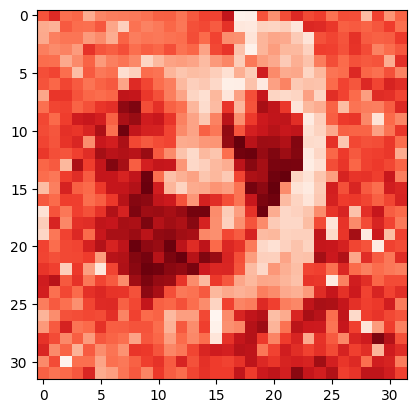

In [89]:
# Canal R
plt.imshow(image[0,:,:,0], cmap="Reds_r")
plt.show()

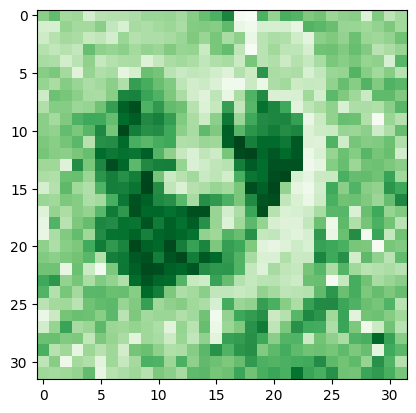

In [90]:
# Canal G
plt.imshow(image[0,:,:,1], cmap="Greens_r")
plt.show()

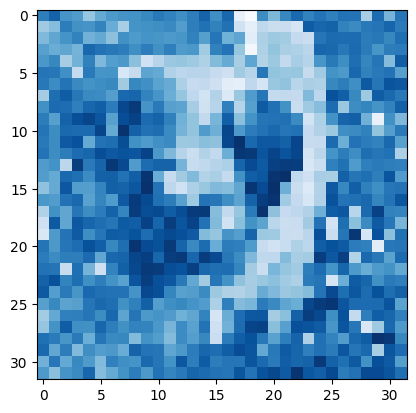

In [91]:
# Canal B
plt.imshow(image[0,:,:,2], cmap="Blues_r")
plt.show()

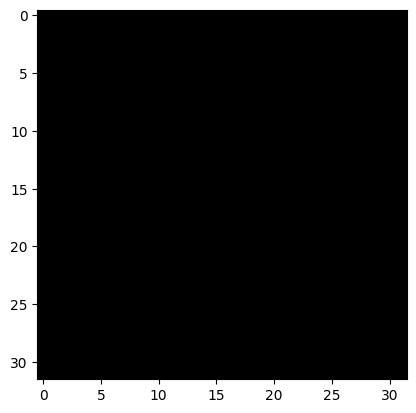

In [92]:
# Canal Alpha
plt.imshow(image[0,:,:,3], cmap="Greys_r")
plt.show()

*Y ahí está, tendremos que quitar ese 4º canal para que la imagen pueda ser usada por nuestro modelo.*

In [93]:
image[:,:,:,:-1].shape

(1, 32, 32, 3)

In [94]:
predictions = model.predict(image[:,:,:,:-1]).round(3)
print("predictions shape:", predictions.shape)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
predictions shape: (1, 1)


array([[0.999]], dtype=float32)